# Wasserstein K-Means

## Example of trading strategy using regimes

In [1]:
import sys

sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import trange

In [3]:
%load_ext autoreload
%autoreload 2

from market_regime_detection.data import compute_log_returns

from market_regime_detection.wasserstein_univariate import (
    split_array_into_windows,
    wasserstein_k_means,
    get_corrected_assignments,
)

## Loading data for RU000A10B7W1

https://mfd.ru/marketdata/ticker/?id=766835#id=766835&start=29.12.2025&aggregateMode=Average&timeframe=1440&i0=EMA&i1=EMA&i1_Period=50&i2=MACD&count=NaN

In [4]:
market_data = pd.read_csv("R_Vision_2_1hour_01112025_27032026.txt", sep=";")

In [5]:
market_data["timestamp"] = pd.to_datetime(
    market_data["<DATE>"].astype(str) + " " + market_data["<TIME>"].astype(str),
    format="%Y%m%d %H%M%S",
)

In [6]:
market_data = market_data.rename(columns={"<CLOSE>": "price"}).set_index("timestamp")[
    ["price"]
]

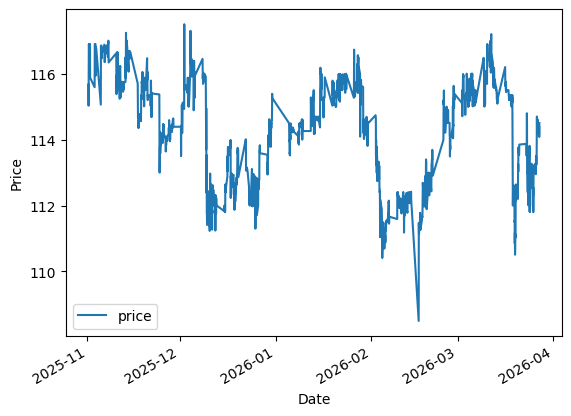

In [7]:
market_data.plot()
plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

Compute log-returns

In [8]:
market_returns = market_data.apply(compute_log_returns, axis=0)
# market_returns = market_returns.set_index(market_data.index[1:].floor("d"))

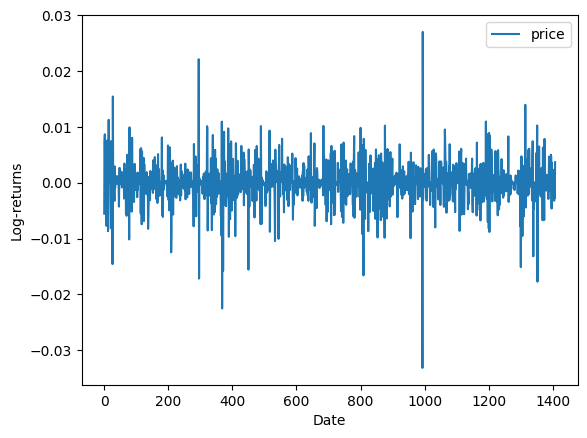

In [9]:
market_returns.plot()
plt.ylabel("Log-returns")
plt.xlabel("Date")
plt.show()

## Clusterization

In [10]:
WINDOW_LENGTH_DAYS = 50  # ~ 5 days

In [11]:
data_for_clustering = split_array_into_windows(
    market_returns=market_returns["price"].to_numpy(), window_shape=WINDOW_LENGTH_DAYS
)

- 2 clusters - bull and bear market
- 3 clusters - bull / neutral / stress
- 4+ clusters - volatility clustering / finer market regimes

In [12]:
assignments, _, _ = wasserstein_k_means(
    chunks=data_for_clustering, n_clusters=2, max_iter=100
)

corrected_assignments = get_corrected_assignments(
    assignments=assignments, window_shape=WINDOW_LENGTH_DAYS
)

In [13]:
np.bincount(corrected_assignments)

array([929, 430])

## Visualization

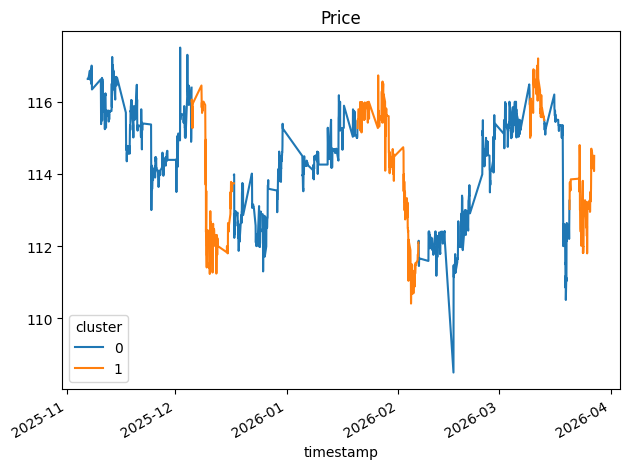

In [14]:
(
    market_data.iloc[WINDOW_LENGTH_DAYS:, :]
    .assign(cluster=corrected_assignments)
    .reset_index()
    .pivot(index="timestamp", columns="cluster", values="price")
    .plot()
)

plt.title("Price")

plt.tight_layout()
plt.show()

## Test trading

In [18]:
test_data = market_data.iloc[WINDOW_LENGTH_DAYS:, :].assign(
    cluster=corrected_assignments
)

+1 (0 -> 1) sell, -1 (1 -> 0) buy

In [139]:
# disregard coupons
# comission is only for selling (0.1%)

In [45]:
port = {"rub": 100_000, "bond": 0}

last_deal_price = np.inf
threshold = 1.0
fee = 0.001

for date, row in test_data.iterrows():
    if (
        row.cluster == 0
        and row.price < last_deal_price * threshold
        and port["bond"] == 0
    ):
        q = np.floor(port["rub"] / (row.price * 10))
        port["bond"] = q
        port["rub"] -= q * row.price * 10
        last_deal_price = row.price
        print(f"Buying {q} bonds for {row.price}")
    elif (
        row.cluster == 1
        and row.price > last_deal_price / threshold
        and port["bond"] > 0
    ):
        q = port["bond"]
        port["rub"] += q * row.price * 10 * (1 - fee)
        port["bond"] = 0
        last_deal_price = row.price
        print(f"Selling {q} bonds for {row.price}")

Buying 85.0 bonds for 116.63
Selling 85.0 bonds for 116.73
Buying 89.0 bonds for 112.09
Selling 89.0 bonds for 115.92
Buying 89.0 bonds for 115.5


In [46]:
if port["bond"] > 0:
    q = port["bond"]
    port["rub"] += q * row.price * 10
    port["bond"] = 0

In [47]:
print(f"Trading gives you {port["rub"] - 100000}")

Trading gives you 2401.310700000031


In [48]:
print(
    f"Holding gives you {100000 * (116.63 / market_data["price"].values[-1] - 1):.2f}"
)

Holding gives you 1860.26
